# Statistics

This section showcases the utility functions found in the [datachart.utils.stats](../../../references/utils/stats) module.

Let us start by importing the supporting libraries:

In [1]:
import math
import random

## Statistics Submodule

The [dataset.utils.stats](../../../references/utils/stats) submodule contains functions for calculating statistics. To showcase
its use, let us create a list of random numbers:


In [2]:
random_values = random.sample(range(1, 100), 10)
random_values

[88, 41, 24, 14, 58, 66, 91, 52, 9, 15]

Let us now showcase the functions in the `stats` module.

### Count

The `count` function returns the number of elements in the list.

In [3]:
from datachart.utils.stats import count

In [4]:
count(random_values)

10

### Sum

The `sum_values` function returns the sum of all values in the list.


In [5]:
from datachart.utils.stats import sum_values

In [6]:
sum_values(random_values)

458.0

### Mean

The `mean` function returns the mean of the values.

In [7]:
from datachart.utils.stats import mean

In [8]:
mean(random_values)

45.8

### Median

The `median` function returns the median of the values. 

In [9]:
from datachart.utils.stats import median

In [10]:
median(random_values)

46.5

### Standard Deviation

The `stdev` function returns the standard deviation of the values.

In [11]:
from datachart.utils.stats import stdev

In [12]:
stdev(random_values)

28.690765064738162

### Variance

The `variance` function returns the variance of the values. Variance is the square of the standard deviation.


In [13]:
from datachart.utils.stats import variance

In [14]:
variance(random_values)

823.1599999999999

### Quantile

The `quantile` function returns the quantile of the values.

In [15]:
from datachart.utils.stats import quantile

Show the 25th quantile:

In [16]:
quantile(random_values, 25)

17.25

Show the 75th quantile:

In [17]:
quantile(random_values, 75)

64.0

### Interquartile Range (IQR)

The `iqr` function returns the interquartile range, which is the difference between the 75th percentile (Q3) and 25th percentile (Q1). It is useful for identifying outliers and understanding the spread of the middle 50% of the data.


In [18]:
from datachart.utils.stats import iqr


In [19]:
iqr(random_values)


46.75

### Minimum

The `minimum` function returns the minimum of the values.

In [20]:
from datachart.utils.stats import minimum

In [21]:
minimum(random_values)

9.0

### Maximum

The `maximum` function returns the maximum of the values.

In [22]:
from datachart.utils.stats import maximum

In [23]:
maximum(random_values)

91.0

### Correlation

The `correlation` function calculates the Pearson correlation coefficient between two lists of values. It measures the linear relationship between the datasets, ranging from -1 (perfect negative correlation) to 1 (perfect positive correlation).


In [24]:
from datachart.utils.stats import correlation

Create a second list of random values to compare:


In [25]:
random_values_2 = random.sample(range(1, 100), 10)
random_values_2

[47, 37, 97, 96, 35, 40, 51, 45, 30, 81]

In [26]:
correlation(random_values, random_values_2)

-0.45201111742439076

### Spearman correlation

The `spearman` function calculates the Spearman rank correlation between two lists of values. It is the Pearson correlation of the ranks, so it captures any monotone relationship (not only a linear one) and is robust to outliers.

In [27]:
from datachart.utils.stats import spearman

In [28]:
spearman(random_values, random_values_2)

-0.05454545454545454

### Mode

The `mode` function returns the most frequent value. It is meant for discrete data, where values repeat; ties are broken by taking the smallest of the most frequent values.

In [29]:
from datachart.utils.stats import mode

In [30]:
mode([3, 1, 2, 3, 1])

1.0

### Skewness

The `skewness` function measures the asymmetry of the values: positive when the tail extends to the right of the bulk, negative when it extends to the left, and zero for a symmetric distribution.

In [31]:
from datachart.utils.stats import skewness

In [32]:
skewness(random_values)

0.23758659341376867

### Kurtosis

The `kurtosis` function measures how heavy the tails are compared to a normal distribution, which scores zero: positive for heavier tails and sharper peaks, negative for lighter tails and flatter shapes.

In [33]:
from datachart.utils.stats import kurtosis

In [34]:
kurtosis(random_values)

-1.3000981892970072

Shape statistics are easiest to read against the distribution they describe. A right-skewed sample drawn on a [datachart.charts.Histogram](../../../references/charts/#datachart.charts.Histogram) with its mean and median as `vlines` shows why the skewness is positive: the tail pulls the mean past the median.

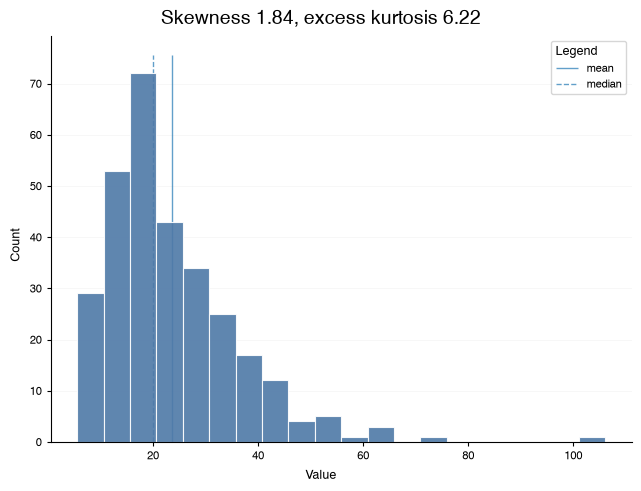

In [35]:
from datachart.charts import Histogram
from datachart.constants import FIG_SIZE, SHOW_GRID

random.seed(5)
skewed_values = [random.lognormvariate(3, 0.5) for _ in range(300)]

Histogram(
    data=[{"x": value} for value in skewed_values],
    vlines=[
        {"x": mean(skewed_values), "label": "mean"},
        {"x": median(skewed_values), "label": "median", "style": {"plot_vline_style": "--"}},
    ],
    title=f"Skewness {skewness(skewed_values):.2f}, excess kurtosis {kurtosis(skewed_values):.2f}",
    xlabel="Value",
    ylabel="Count",
    show_legend=True,
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Linear fit

The `linear_fit` function fits a straight line `y = slope * x + intercept` to two lists of values and returns `(slope, intercept, r2)`, where `r2` says how much of the variation in `y` the line explains (1 is a perfect fit).

In [36]:
from datachart.utils.stats import linear_fit

In [37]:
slope, intercept, r2 = linear_fit(random_values, random_values_2)
slope, intercept, r2

(-0.38160260459691925, 73.3773992905389, 0.20431405027524632)

The fit is a trend line: evaluate `slope * x + intercept` at the two ends of the x range and draw it as a [datachart.charts.LineChart](../../../references/charts/#datachart.charts.LineChart) over the [datachart.charts.ScatterChart](../../../references/charts/#datachart.charts.ScatterChart) of the points with [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel). The `r2` goes in the title.

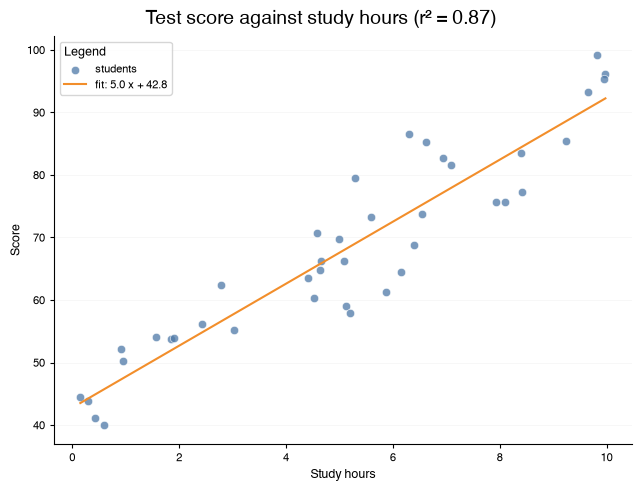

In [38]:
from datachart.charts import LineChart, ScatterChart
from datachart.utils import Panel

random.seed(11)
hours = [random.uniform(0, 10) for _ in range(40)]
scores = [40 + 5 * hour + random.gauss(0, 8) for hour in hours]
slope, intercept, r2 = linear_fit(hours, scores)

Panel(
    [
        ScatterChart(data=[{"x": x, "y": y} for x, y in zip(hours, scores)], subtitle="students"),
        LineChart(
            data=[{"x": x, "y": slope * x + intercept} for x in (min(hours), max(hours))],
            subtitle=f"fit: {slope:.1f} x + {intercept:.1f}",
        ),
    ],
    title=f"Test score against study hours (r² = {r2:.2f})",
    xlabel="Study hours",
    ylabel_left="Score",
    show_legend=True,
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Bootstrap confidence interval

The `bootstrap_ci` function estimates a confidence interval of a statistic (the `mean` by default) by resampling the values with replacement `n_resamples` times and taking the central `level` share of the results. Pass a `seed` to make the interval reproducible.

In [39]:
from datachart.utils.stats import bootstrap_ci

In [40]:
low, high = bootstrap_ci(random_values, level=0.95, seed=42)
low, high

(28.997500000000002, 64.205)

The interval is a ready-made error bar. To show the uncertainty of each group's mean on a [datachart.charts.BarChart](../../../references/charts/#datachart.charts.BarChart), set each bar's `y` to the group mean and its `yerr` to the half-width of the interval, then turn on `show_yerr`:

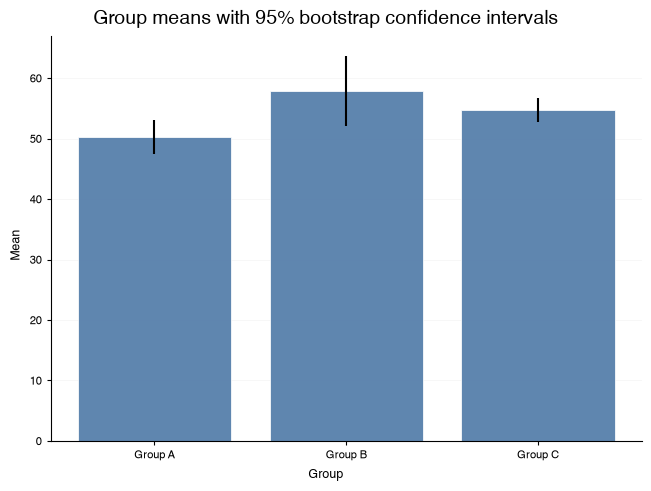

In [41]:
from datachart.charts import BarChart

random.seed(7)
groups = {
    "Group A": [random.gauss(50, 10) for _ in range(30)],
    "Group B": [random.gauss(60, 20) for _ in range(30)],
    "Group C": [random.gauss(55, 5) for _ in range(30)],
}

data = []
for label, values in groups.items():
    low, high = bootstrap_ci(values, seed=42)
    data.append({"label": label, "y": mean(values), "yerr": (high - low) / 2})

BarChart(
    data=data,
    title="Group means with 95% bootstrap confidence intervals",
    xlabel="Group",
    ylabel="Mean",
    show_yerr=True,
).show()

### Histogram

The `histogram` function bins the values and returns the `(counts, edges)` lists, with one more edge than counts. The `bins` argument is passed straight to `numpy.histogram_bin_edges`: a rule name such as `"auto"`, `"fd"`, or `"rice"` picks the edges from the data, an integer sets the number of equal-width bins, and a list gives the edges explicitly.

In [42]:
from datachart.utils.stats import histogram

In [43]:
counts, edges = histogram(random_values, bins=4)
counts, edges

([4, 1, 3, 2], [9.0, 29.5, 50.0, 70.5, 91.0])

The counts and edges are a bar chart in waiting: label each bar with its lower edge and draw the counts with a [datachart.charts.BarChart](../../../references/charts/#datachart.charts.BarChart). Unlike the [datachart.charts.Histogram](../../../references/charts/#datachart.charts.Histogram) front, which takes an integer `num_bins`, the bin rule picks the number of bins from the data — here Freedman–Diaconis on the skewed sample above.

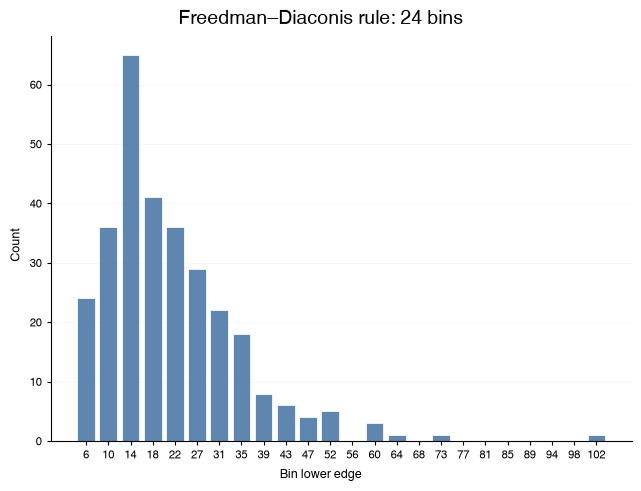

In [44]:
counts, edges = histogram(skewed_values, bins="fd")

BarChart(
    data=[{"label": f"{low:.0f}", "y": count} for count, low in zip(counts, edges)],
    title=f"Freedman–Diaconis rule: {len(counts)} bins",
    xlabel="Bin lower edge",
    ylabel="Count",
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Rolling mean

The `rolling_mean` function smooths a series with a trailing moving average. Each output is the mean of the `window` values ending at that index, so the result lines up with the input and is `nan` until the window fills. Let us create a noisy series to smooth:

In [45]:
from datachart.utils.stats import rolling_mean

In [46]:
random.seed(3)
noisy_series = [value + random.gauss(0, 10) for value in range(0, 120, 10)]
noisy_series

[0.9470803828730423,
 22.500243810835503,
 10.68621632279293,
 39.9237728051924,
 37.40845462306566,
 47.38489016018826,
 78.99725278464757,
 71.57537071633719,
 79.57075746207755,
 97.2949848643561,
 111.26853962383855,
 109.6915672496507]

In [47]:
rolling_mean(noisy_series, window=3)

[nan,
 nan,
 11.377846838833825,
 24.37007764627361,
 29.33948125035033,
 41.5723725294821,
 54.59686585596717,
 65.98583788705768,
 76.71446032102078,
 82.81370434759027,
 96.04476065009072,
 106.08503057928179]

### Exponentially weighted moving average

The `ewma` function smooths a series by blending each value with the previous output, `alpha * value + (1 - alpha) * previous`. A larger `alpha` follows the data more closely; a smaller one smooths harder.

In [48]:
from datachart.utils.stats import ewma

In [49]:
ewma(noisy_series, alpha=0.3)

[0.9470803828730423,
 7.41302941126178,
 8.394985484721126,
 17.853621680862506,
 23.72007156352345,
 30.819517142522894,
 45.272837835160296,
 53.16359769951336,
 61.08574562828261,
 71.94851739910465,
 83.7445240665248,
 91.52863702146257]

Both smoothers line up with the input, so they draw as extra series of one [datachart.charts.LineChart](../../../references/charts/#datachart.charts.LineChart) over the raw values. The rolling mean starts once its window fills (the leading `nan` values leave a gap); the EWMA starts at once but lags behind turns.

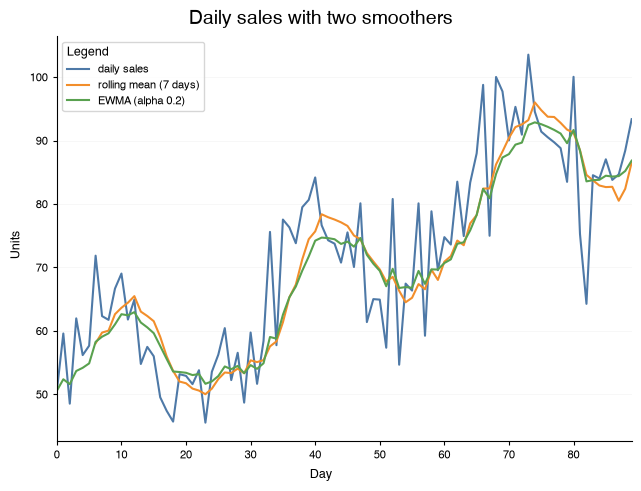

In [50]:
random.seed(3)
daily_sales = [50 + 0.5 * day + 8 * math.sin(day / 5) + random.gauss(0, 6) for day in range(90)]

series = {
    "daily sales": daily_sales,
    "rolling mean (7 days)": rolling_mean(daily_sales, window=7),
    "EWMA (alpha 0.2)": ewma(daily_sales, alpha=0.2),
}

LineChart(
    data=[[{"x": day, "y": value} for day, value in enumerate(values)] for values in series.values()],
    subtitle=list(series),
    title="Daily sales with two smoothers",
    xlabel="Day",
    ylabel="Units",
    show_legend=True,
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

When the raw series is context rather than the message, mute it instead of giving it an equal color: `emphasis` (see the [emphasis guide](../styling/highlighting)) greys the raw line and drops it from the legend, and [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) draws the smoothed series over it in the palette color.

In [ ]:
from datachart.constants import EMPHASIS

Panel(
    [
        LineChart(
            data=[{"x": day, "y": value} for day, value in enumerate(daily_sales)],
            emphasis=EMPHASIS.BACKGROUND,
        ),
        LineChart(
            data=[
                {"x": day, "y": value}
                for day, value in enumerate(rolling_mean(daily_sales, window=7))
            ],
            subtitle="rolling mean (7 days)",
        ),
    ],
    title="Daily sales behind its 7-day mean",
    xlabel="Day",
    ylabel_left="Units",
    show_legend=True,
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### LOESS

The `loess` function smooths `(x, y)` points with a locally weighted linear fit: at each `x` a line is fitted to the nearest `frac` share of the points, weighted so closer points count more. It returns `{x, y}` points sorted by `x`, ready to draw as a [datachart.charts.LineChart](../../../references/charts/#datachart.charts.LineChart) over the raw points. The fit runs on numbers, so a datetime `x` goes through `matplotlib.dates.date2num` on the way in and `num2date` on the way back.

In [51]:
from datachart.utils.stats import loess

In [52]:
loess(list(range(len(noisy_series))), noisy_series, frac=0.5)

[{'x': 0.0, 'y': 3.9280143962464633},
 {'x': 1.0, 'y': 13.154569956130818},
 {'x': 2.0, 'y': 22.910476952585203},
 {'x': 3.0, 'y': 30.786015062451888},
 {'x': 4.0, 'y': 42.09861840084702},
 {'x': 5.0, 'y': 54.60586891653355},
 {'x': 6.0, 'y': 64.88569263807604},
 {'x': 7.0, 'y': 75.68113186438893},
 {'x': 8.0, 'y': 85.17919943608804},
 {'x': 9.0, 'y': 95.0003442617521},
 {'x': 10.0, 'y': 104.90722673451698},
 {'x': 11.0, 'y': 114.64220933245653}]

Because `loess` returns `{x, y}` points, the smoothed curve overlays the [datachart.charts.ScatterChart](../../../references/charts/#datachart.charts.ScatterChart) of the raw points through [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) — a non-linear trend a straight `linear_fit` would miss.

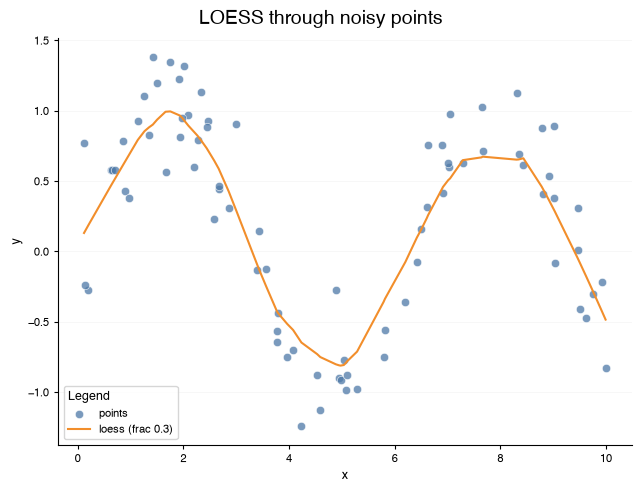

In [53]:
random.seed(8)
x_points = [random.uniform(0, 10) for _ in range(80)]
y_points = [math.sin(x) + random.gauss(0, 0.3) for x in x_points]

Panel(
    [
        ScatterChart(data=[{"x": x, "y": y} for x, y in zip(x_points, y_points)], subtitle="points"),
        LineChart(data=loess(x_points, y_points, frac=0.3), subtitle="loess (frac 0.3)"),
    ],
    title="LOESS through noisy points",
    xlabel="x",
    ylabel_left="y",
    show_legend=True,
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Kernel density estimate

The `kde1d` function estimates the density of a list of values with a Gaussian kernel and returns it as `{x, y}` points, ready to draw as a [datachart.charts.LineChart](../../../references/charts/#datachart.charts.LineChart) — over a density [datachart.charts.Histogram](../../../references/charts/#datachart.charts.Histogram) of the same values, for instance. The `bandwidth` is a rule of [datachart.constants.BANDWIDTH](../../../references/constants/#datachart.constants.BANDWIDTH) or a scalar factor, `gridsize` the number of points, and `cut` how many bandwidths the curve extends past the extremes (`xlim` fixes the range instead).

In [54]:
from datachart.utils.stats import kde1d

In [55]:
curve = kde1d(random_values, gridsize=5)
curve

[{'x': -48.245602321297724, 'y': 4.370945528864106e-05},
 {'x': 0.8771988393511378, 'y': 0.006470031844980029},
 {'x': 50.0, 'y': 0.009607065243376943},
 {'x': 99.12280116064886, 'y': 0.004462559438356162},
 {'x': 148.24560232129772, 'y': 3.776836178537969e-05}]

Drawn as a [datachart.charts.LineChart](../../../references/charts/#datachart.charts.LineChart) with `show_area`, the curve is the density chart of the skewed sample; the [Histogram guide](../../charts/histogram/#density-curve) overlays it on a density histogram.

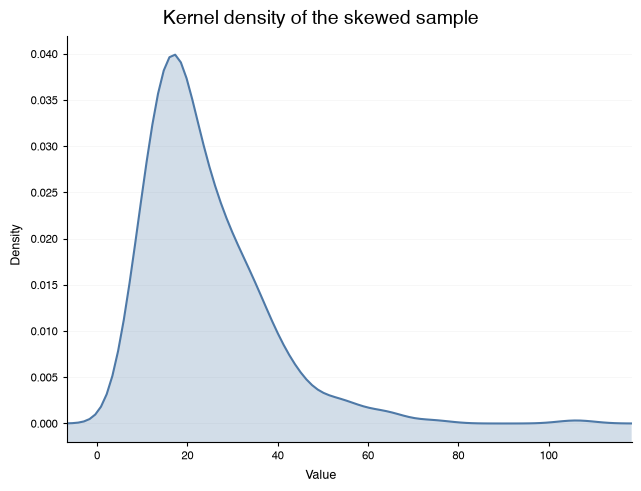

In [56]:
LineChart(
    data=kde1d(skewed_values),
    title="Kernel density of the skewed sample",
    xlabel="Value",
    ylabel="Density",
    show_area=True,
    show_grid=SHOW_GRID.Y,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

The `kde2d` function does the same for `(x, y)` points and returns the `{x, y, z}` surface a [datachart.charts.ContourChart](../../../references/charts/#datachart.charts.ContourChart) draws — the density contours of a scattered dataset. The `gridsize` can be one number or an `(x, y)` pair of column and row counts, and `xlim`/`ylim` fix the grid so several surfaces share it.

In [57]:
from datachart.utils.stats import kde2d

In [58]:
surface = kde2d(random_values, random_values_2, gridsize=3)
surface

{'x': [-52.812379539026765, 50.000000000000014, 152.81237953902678],
 'y': [-22.184037337027505, 63.500000000000014, 149.18403733702752],
 'z': [[3.667428917624081e-12, 5.311584821185632e-07, 1.095625430513155e-08],
  [4.570301346663002e-07, 0.00010392184155294512, 4.735536093441602e-08],
  [7.425859504168512e-08, 8.46009598538858e-09, 2.449171564449554e-20]]}